In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from IPython.display import display


from source_code.galdist import galaxy_distribution
from source_code.gwdist import gw_distribution

from source_code.fisher     import get_Fisher
from source_code.likelihood import LSSlike

from cobaya.run import run

from getdist.gaussian_mixtures import GaussianND
from copy import deepcopy
from getdist import plots,loadMCSamples,MCSamples

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

# Settings

## Options

In [2]:
mock_path  = './mock_data/new_LSS_LCDM_thetamin'
mock_label = r'3$\times$2pt'
camb_path = '/home/Matteo/Codes/GW-MGCAMB'
observables = ['GC','WL','GWC','GWWL']
dist_file = mock_path+'_source_distribution.npy'

bin_to_plot = [1,3,6]

covmats_ells_toplot = [5,-1]

test_parameter = {'name': 'a1',
                  'variation': 0.1,
                  'latex': r'$a_1$',
                  'Ngrid': 10}



run_tests = False

## Specifications

In [3]:
galspecs = {'fsky': 0.35,
            'gal_per_arcmin': 30.,
            'sigma_eps': 0.3}

gwspecs  = {'N_gw': int(1.e6),
            'sigma_eps_gw': 0.01,
            'fsky': 0.35,
            'theta_min': 0.01}

## Fiducial

In [4]:
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'H0': 67.,
            'ns': 0.96,
            'logA': 3.05685,
            'a0': -0.007589,
            'a1': 0.002008,
            'a2': -0.004127,
            'a3': 0.002918,
            'a4': -0.0006784,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292,
            'b0_poly_GW': 0.830703,
            'b1_poly_GW': 1.190547,
            'b2_poly_GW': -0.928357,
            'b3_poly_GW': 0.423292,
            'tau': 0.05,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            #MG params
            'mu0': 0.,
            'sigma0': 0.,
            'MG_flag': 1,
            'pure_MG_flag': 2,
            'musigma_par': 1,
            'DE_model': 0}

# Generate distributions

In [5]:
distributions = {}

if 'GC' in observables:
    dist = galaxy_distribution(survey='Euclid-10')
    bin_lims = dist.galdict['bin_lims']
    bin_mids = 0.5*(bin_lims[:-1]+bin_lims[1:])
    Nbins_gc = len(bin_lims)-1
    
    distributions['GC'] = {'dist': dist.galdict['binned_dist'],
                           'Nbins': Nbins_gc,
                           'zmean': bin_mids}
    
if 'WL' in observables:
    dist = galaxy_distribution(survey='Euclid-10')
    bin_lims = dist.galdict['bin_lims']
    bin_mids = 0.5*(bin_lims[:-1]+bin_lims[1:])
    Nbins_wl = len(bin_lims)-1
    
    distributions['WL'] = {'dist': dist.galdict['binned_dist'],
                           'Nbins': Nbins_wl,
                           'zmean': bin_mids}
    
if 'GWC' in observables:
    
    gwdist  = gw_distribution('ET-6')
    
    
    bin_lims = gwdist.gwdict['bin_lims']
    bin_mids = 0.5*(bin_lims[:-1]+bin_lims[1:])
    Nbins_gwc = len(bin_lims)-1
    
    distributions['GWC'] = {'dist': gwdist.gwdict['binned_dist'],
                           'Nbins': Nbins_gwc,
                           'zmean': bin_mids}
if 'GWWL' in observables:
    gwdist  = gw_distribution('ET-6')
    
    
    bin_lims = gwdist.gwdict['bin_lims']
    bin_mids = 0.5*(bin_lims[:-1]+bin_lims[1:])
    Nbins_gwl = len(bin_lims)-1
    
    distributions['GWWL'] = {'dist': gwdist.gwdict['binned_dist'],
                           'Nbins': Nbins_gwl,
                           'zmean': bin_mids}

## Saving distributions

(needed to make the fiducial through Fisher work)

In [6]:
np.save(mock_path+'_source_distribution.npy',distributions)

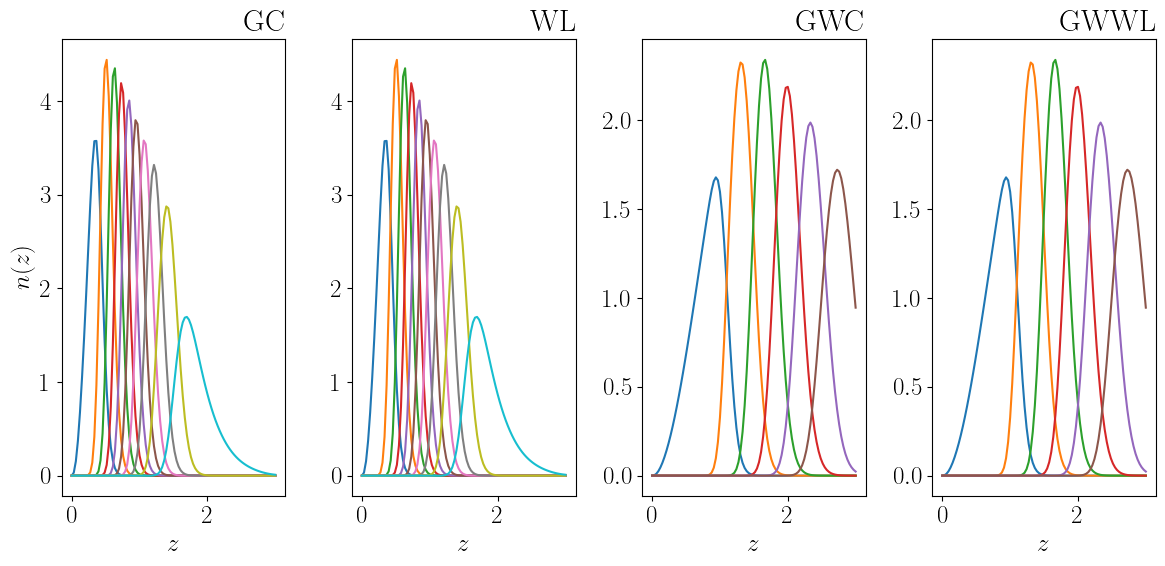

In [7]:
zplot = np.linspace(0.001,3,100)
fig, temp_axes = plt.subplots(figsize=(12,6),ncols=len(observables),nrows=1)
if len(observables) > 1:
    axes = temp_axes
else:
    axes = [temp_axes]
x = np.linspace(0, 10, 100)
for i,obs in enumerate(observables):
    for ibin in range(distributions[obs]['Nbins']):
        axes[i].plot(zplot,distributions[obs]['dist'][ibin](zplot))
            
    axes[i].set_title(obs,loc='right')
    axes[i].set_xlabel(r'$z$')

axes[0].set_ylabel(r'$n(z)$')
    
plt.tight_layout();

# Create dictionaries

In [8]:
general_info = {'obs_settings': {'extra': None,
                                 'case': 'simple',
                                 'camb_path': camb_path,
                                 'calculation': 'CAMB'},
        
                'analysis_settings': {'dist_path': dist_file,
                                      'lmin': 10,
                                      'lmax': 1500,
                                      'Nbin_ell': 20,
                                      'galaxy_specs': galspecs,
                                      'GW_specs': gwspecs}}

## Fisher dictionary

In [9]:
fish_info = deepcopy(general_info)
fish_info['sampler'] = {'Fisher': {'derivative': 'polynomial',
                                   'freepars': {test_parameter['name']: {'fiducial': fiducial[test_parameter['name']],
                                                                         'variation': test_parameter['variation'],
                                                                         'latex': test_parameter['latex']}},
                                   'fixedpars': {par: val for par,val in fiducial.items() if par != test_parameter['name']}}}

## Likelihood dictionary


**We could edit this cell to automatically create the yaml file to be use depending on options**

In [10]:
like_info = deepcopy(general_info)
like_info['likelihood'] = {'LSS': {'external': LSSlike,
                                   'data_path': mock_path,
                                   'debug_mode': False,
                                   'settings': {'case': 'simple',
                                                'calculation': 'CAMB',
                                                'extra': None,
                                                'camb_path': camb_path},
                                   'use_noiseless_cls': True}}

like_info['params'] = deepcopy(fiducial)
like_info['params']['As'] = {'latex': 'A_\mathrm{s}',
                             'value': 'lambda logA: 1e-10*np.exp(logA)'}

like_info['params'][test_parameter['name']] = {'prior': {'min': fiducial[test_parameter['name']]*(1-2*test_parameter['variation']),
                                                         'max': fiducial[test_parameter['name']]*(1+2*test_parameter['variation'])},
                                               'ref': fiducial[test_parameter['name']],
                                               'latex': test_parameter['latex']}

# Initialize Fisher module and get fiducial

In [11]:
lmin = np.log10(fish_info['analysis_settings']['lmin'])
lmax = np.log10(fish_info['analysis_settings']['lmax'])
N    = fish_info['analysis_settings']['Nbin_ell']

obs_settings = fish_info['obs_settings']
if obs_settings['extra'] == None:
    obs_settings['extra'] = {}
    
ell_lims = np.logspace(lmin,lmax,N) #creation of array-> N bin log spaced
ells     = np.array([int(ell) for ell in 0.5*(ell_lims[:-1]+ell_lims[1:])])
deltas   = (ell_lims[1:]-ell_lims[:-1]) #evaluation of the amplitude of each bin

distributions = np.load(fish_info['analysis_settings']['dist_path'],allow_pickle=True).item()
galaxy_specs  = fish_info['analysis_settings']['galaxy_specs']

free_params = fish_info['sampler']['Fisher']['freepars']

#MMmod: to be changed to work only with GW only?#####
if 'GWWL' in distributions or 'GWC' in distributions:
    GW_specs = fish_info['analysis_settings']['GW_specs']
else:
    GW_specs = {}
    
    

fiducial_pars = {par: pardict['fiducial'] for par,pardict in free_params.items()} | fish_info['sampler']['Fisher']['fixedpars']
dertype  = fish_info['sampler']['Fisher']['derivative']

fishmodule = get_Fisher(fiducial_pars,free_params,ells,deltas,distributions,obs_settings,galaxy_specs,GW_specs,dertype)

fiducial_obs = fishmodule.fidobs


Computing fiducial observables...
...done in 89.74 s


### Plotting Fiducial

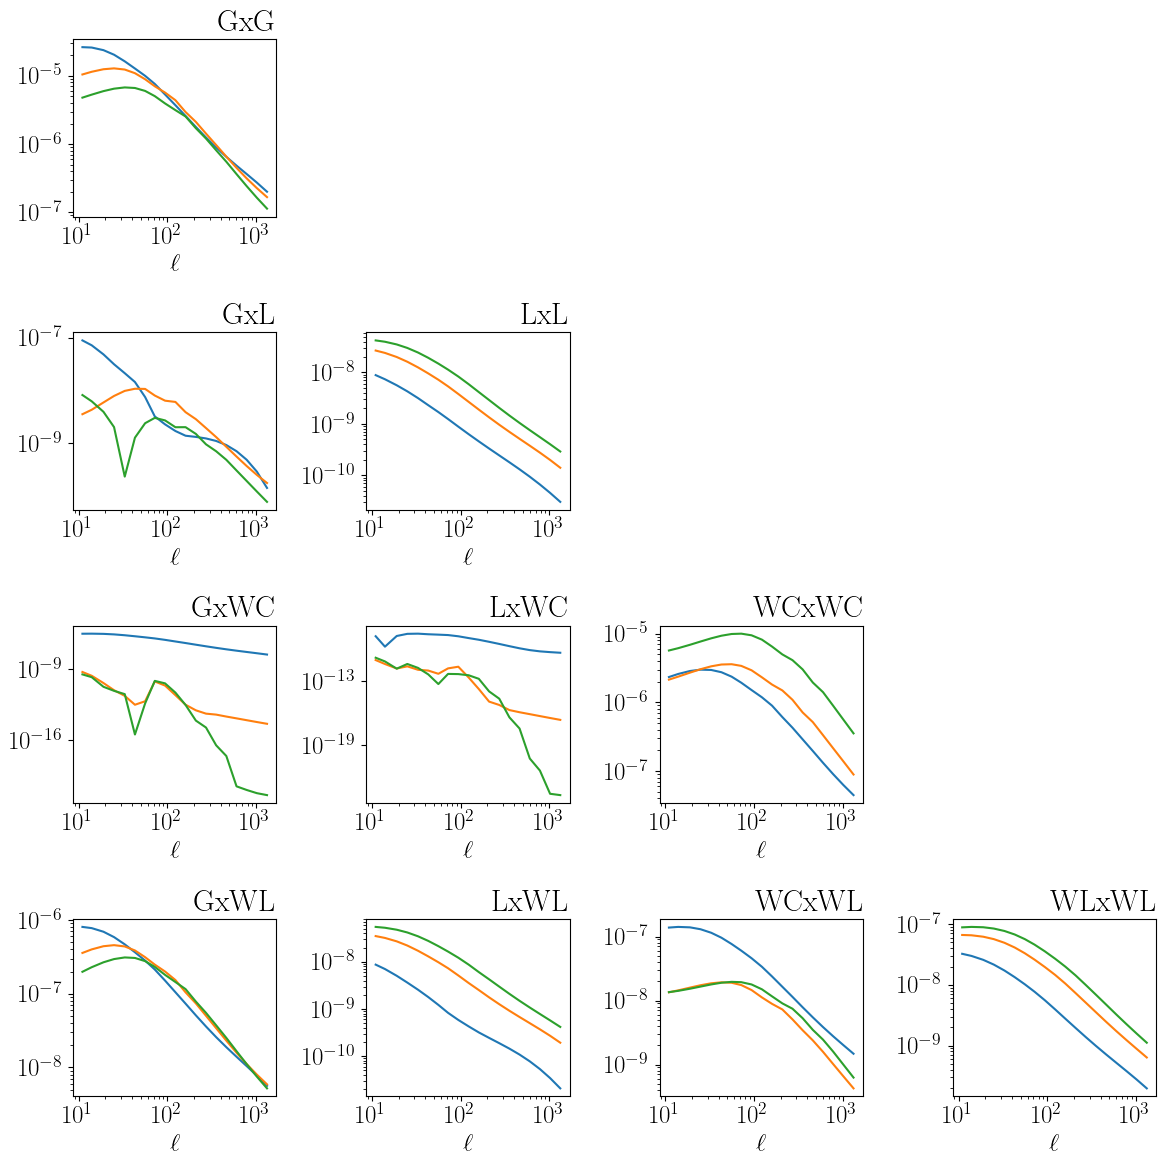

In [12]:
fig, temp_axes = plt.subplots(figsize=(12,12),ncols=len(fishmodule.renamed_obs),nrows=len(fishmodule.renamed_obs))
if len(fishmodule.renamed_obs) > 1:
    axes = temp_axes
else:
    axes = np.array([[temp_axes]])
x = np.linspace(0, 10, 100)
for j,obs1 in enumerate(fishmodule.renamed_obs):
    for i,obs2 in enumerate(fishmodule.renamed_obs):
        if i<j:
            axes[i,j].axis('off')
        else:
            df = pd.melt(fiducial_obs.abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)
            
            axes[i,j].set_title(obs1+'x'+obs2,loc='right')
            #if obs1+obs2 != 'GL':
            #    axes[i,j].set_yscale('log')

for ax in axes.reshape(-1): 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('')
    
plt.tight_layout();

# Get covmat

In [13]:
covmat   = fishmodule.compute_covmat()
all_cols = fishmodule.columns_ordering()
    
covmats_by_ell = [fishmodule.pack_covmat(covmat,ellind,all_cols) for ellind,ell in enumerate(fishmodule.fidobs['ells'])]

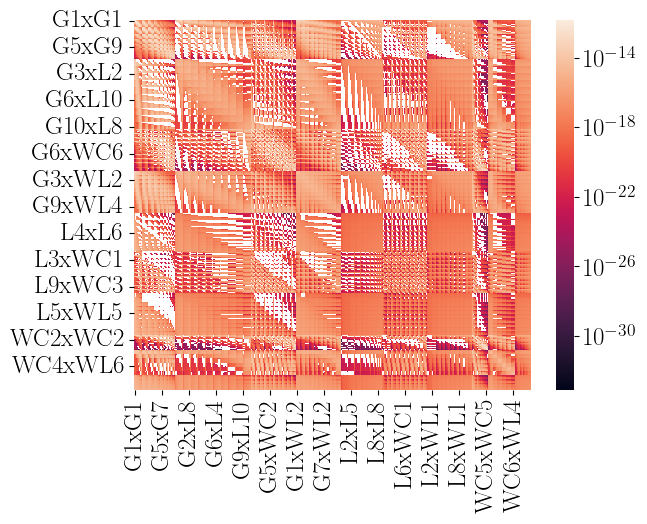

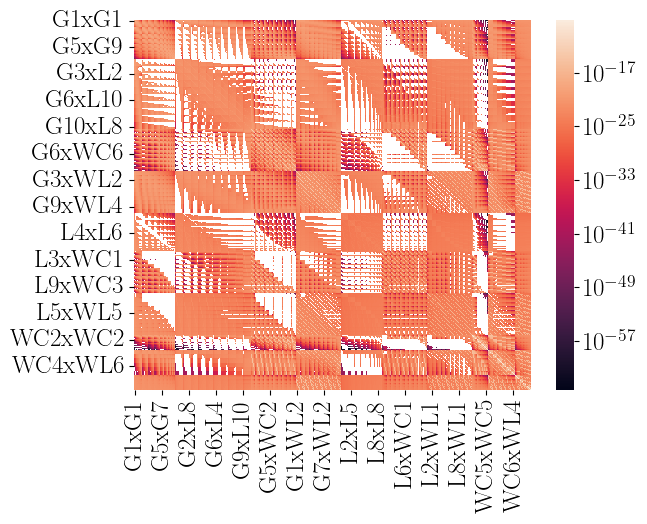

In [14]:
for ind in covmats_ells_toplot:
    plt.figure()
    sb.heatmap(covmats_by_ell[ind],norm=LogNorm())

## Plotting noise

In [15]:
noise = fishmodule.noise

full_noise = pd.DataFrame({'ells': noise['ells']})
for col in noise.columns:
    if col != 'ells':
        full_noise[col] = np.sqrt((2/((2*noise['ells']+1)*galaxy_specs['fsky']*deltas))*(fiducial_obs[col]+noise[col])**2)

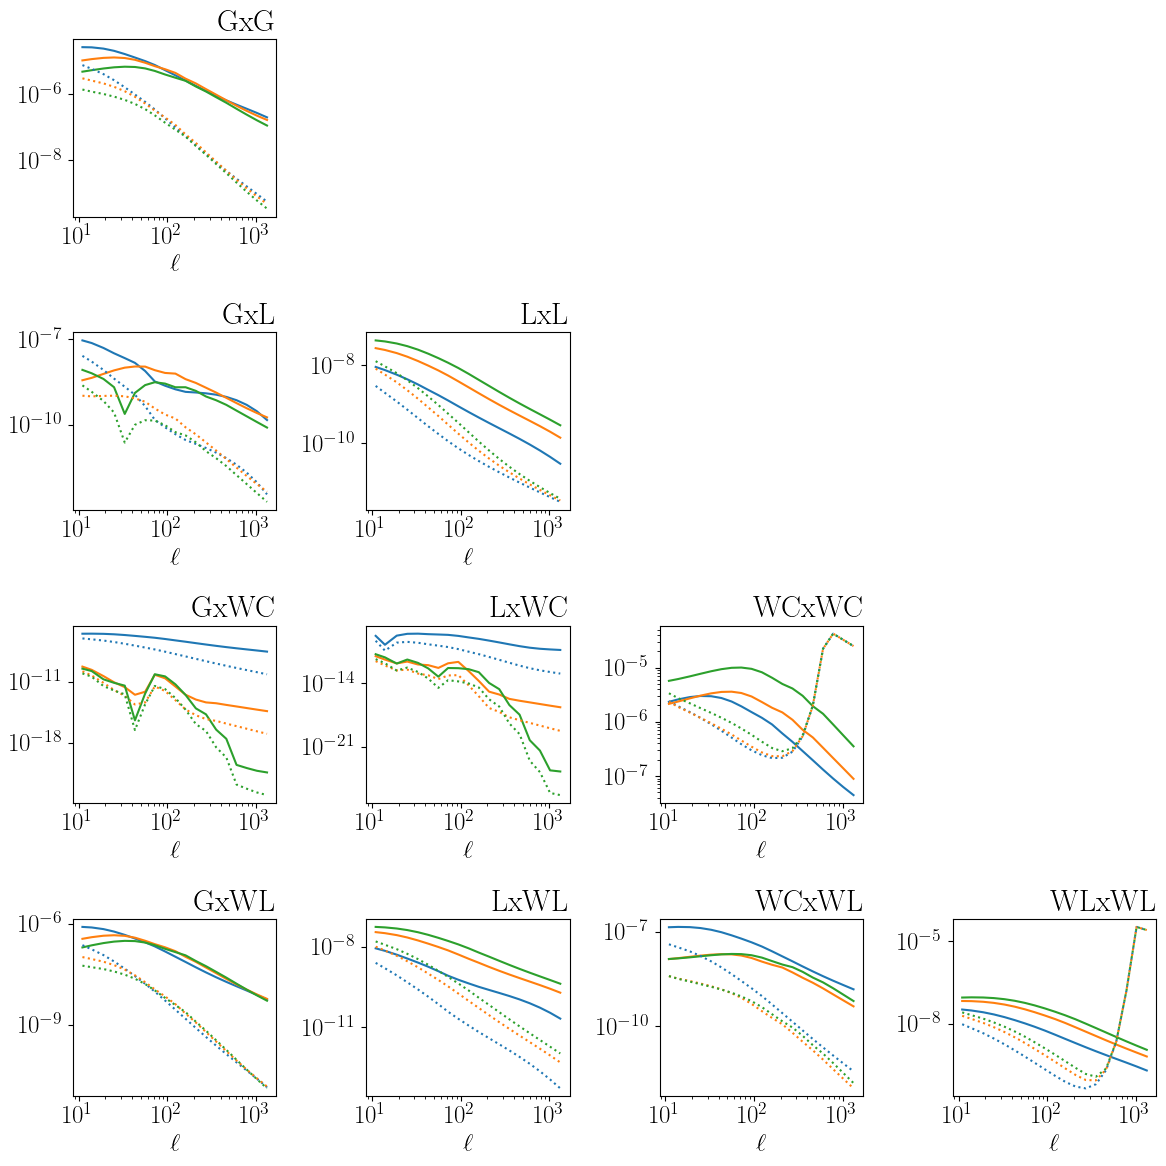

In [16]:
fig, temp_axes = plt.subplots(figsize=(12,12),ncols=len(fishmodule.renamed_obs),nrows=len(fishmodule.renamed_obs))
if len(fishmodule.renamed_obs) > 1:
    axes = temp_axes
else:
    axes = np.array([[temp_axes]])
x = np.linspace(0, 10, 100)
for j,obs1 in enumerate(fishmodule.renamed_obs):
    for i,obs2 in enumerate(fishmodule.renamed_obs):
        if i<j:
            axes[i,j].axis('off')
        else:
            df = pd.melt(fiducial_obs.abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)

            df = pd.melt(full_noise,id_vars=['ells'],value_vars=[obs1+str(i)+'x'+obs2+str(i) for i in bin_to_plot],
                             value_name='value',var_name='Bin')
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0,linestyle=':')
            
            axes[i,j].set_title(obs1+'x'+obs2,loc='right')
            #if obs1+obs2 != 'GL':
            #    axes[i,j].set_yscale('log')

for ax in axes.reshape(-1): 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('')
    
plt.tight_layout();

# Generate and store dataset

In [17]:
theoryvec = fishmodule.fidobs[all_cols]
datavec = pd.DataFrame(columns=all_cols,index=theoryvec.index,dtype='float')
errvec  = pd.DataFrame(columns=all_cols,index=theoryvec.index,dtype='float')
for ellind,ell in enumerate(fishmodule.fidobs['ells']):
    datavec.iloc[ellind] = np.random.multivariate_normal(theoryvec.iloc[ellind],covmats_by_ell[ellind])
    errvec.iloc[ellind]  = np.sqrt(np.diag(covmats_by_ell[ellind]))

theoryvec['ells'] = fishmodule.fidobs['ells']
datavec['ells']   = fishmodule.fidobs['ells']

In [18]:
covmat_dict = {str(int(ell)): covmats_by_ell[ellind] for ellind,ell in enumerate(fishmodule.fidobs['ells'])}

if mock_path != '':
    theoryvec.to_csv(mock_path+'_Cls_noiseless.dat',sep='\t',header=True)
    datavec.to_csv(mock_path+'_Cls_noisy.dat',sep='\t',header=True)
    np.save(mock_path+'_covmat.npy',covmat_dict)

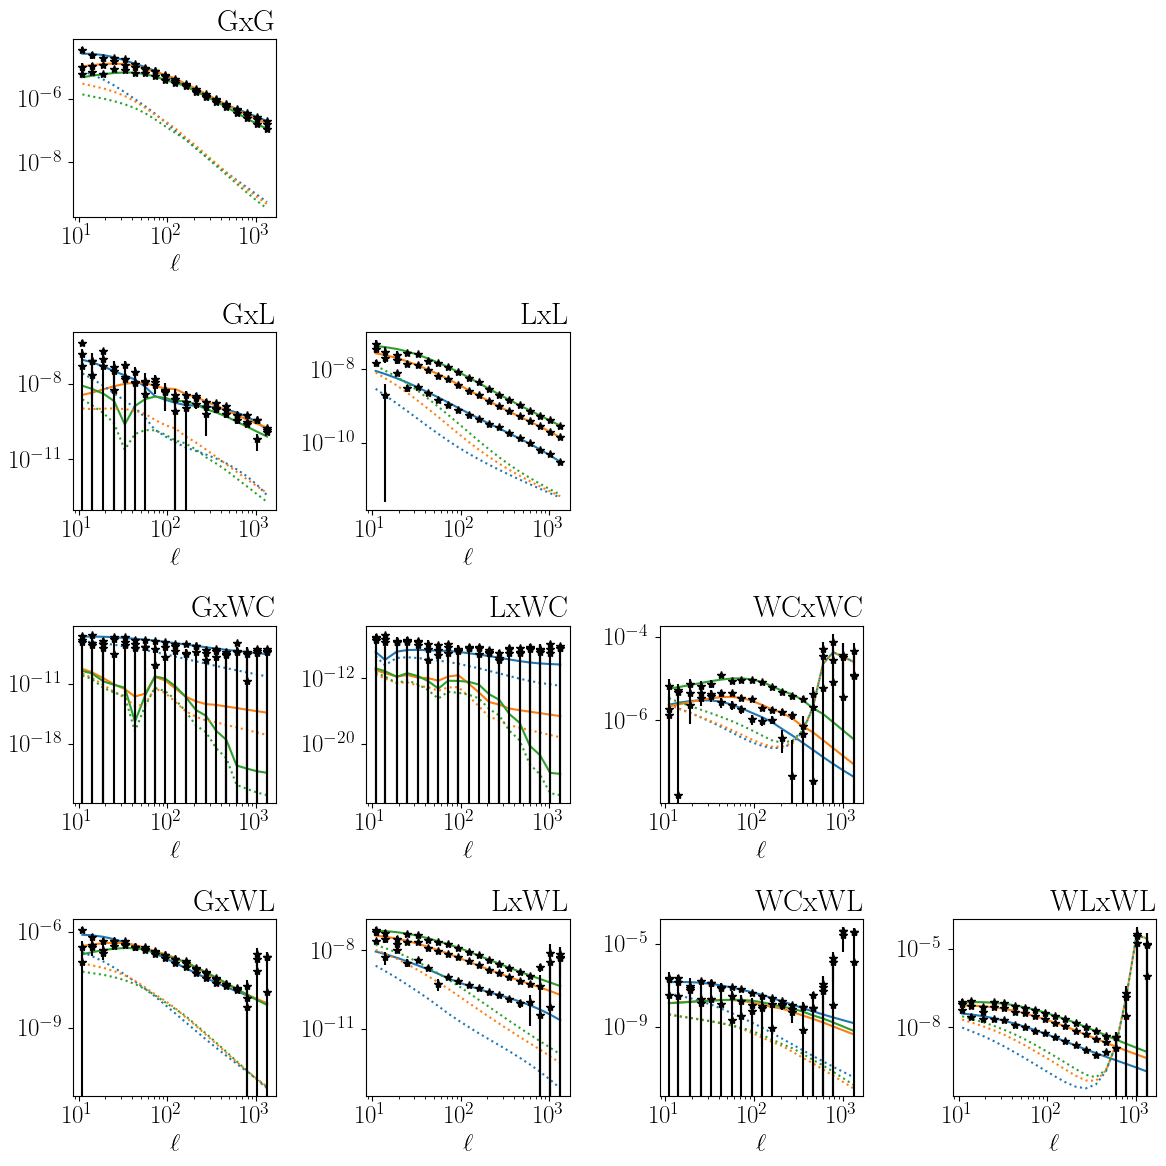

In [19]:
fig, temp_axes = plt.subplots(figsize=(12,12),ncols=len(fishmodule.renamed_obs),nrows=len(fishmodule.renamed_obs))
if len(fishmodule.renamed_obs) > 1:
    axes = temp_axes
else:
    axes = np.array([[temp_axes]])
x = np.linspace(0, 10, 100)
for j,obs1 in enumerate(fishmodule.renamed_obs):
    for i,obs2 in enumerate(fishmodule.renamed_obs):
        if i<j:
            axes[i,j].axis('off')
        else:
            df = pd.melt(fiducial_obs.abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)

            df = pd.melt(full_noise,id_vars=['ells'],value_vars=[obs1+str(i)+'x'+obs2+str(i) for i in bin_to_plot],
                             value_name='value',var_name='Bin')
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0,linestyle=':')

            for bi in bin_to_plot:
                axes[i,j].errorbar(fishmodule.fidobs['ells'],abs(datavec[obs1+str(bi)+'x'+obs2+str(bi)]),
                                   yerr=errvec[obs1+str(bi)+'x'+obs2+str(bi)],marker='*',ls='',color='black')

            
            axes[i,j].set_title(obs1+'x'+obs2,loc='right')
            #if obs1+obs2 != 'GL':
            #    axes[i,j].set_yscale('log')

for ax in axes.reshape(-1): 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('')
    
plt.tight_layout();

# TESTING

In [20]:
if not run_test:
    import sys
    sys.exit('stopping here')

NameError: name 'run_test' is not defined

## Fiducial test

## Internal

In [ ]:
like_info['sampler'] = {'evaluate': {'override': {test_parameter['name']: fiducial[test_parameter['name']]}}}

updated_info,sampler = run(like_info)

## Manual

In [ ]:
from source_code.compute_obs_sources import get_obs

myfiducial = get_obs(fiducial,distributions,fishmodule.fidobs['ells'],general_info['obs_settings'])

In [ ]:
fig, temp_axes = plt.subplots(figsize=(12,12),ncols=len(fishmodule.renamed_obs),nrows=len(fishmodule.renamed_obs))
if len(fishmodule.renamed_obs) > 1:
    axes = temp_axes
else:
    axes = np.array([[temp_axes]])
x = np.linspace(0, 10, 100)
for j,obs1 in enumerate(fishmodule.renamed_obs):
    for i,obs2 in enumerate(fishmodule.renamed_obs):
        if i<j:
            axes[i,j].axis('off')
        else:
            df = pd.melt(fiducial_obs.abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)

            df = pd.melt(myfiducial.Cls.abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0,linestyle=':')

            for bi in bin_to_plot:
                axes[i,j].errorbar(fishmodule.fidobs['ells'],abs(datavec[obs1+str(bi)+'x'+obs2+str(bi)]),
                                   yerr=errvec[obs1+str(bi)+'x'+obs2+str(bi)],marker='*',ls='',color='black')

            
            axes[i,j].set_title(obs1+'x'+obs2,loc='right')
            #if obs1+obs2 != 'GL':
            #    axes[i,j].set_yscale('log')

for ax in axes.reshape(-1): 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('')
    
plt.tight_layout();

In [ ]:
mydiffvec = pd.DataFrame({'ells': myfiducial.Cls['ells']})
for col in theoryvec.columns:
    if col != 'ells':
        mydiffvec[col] = myfiducial.Cls[col]-theoryvec[col]

In [ ]:
tempdiff = mydiffvec.drop(columns=['ells'])
chi2 = 0
for ind,ell in enumerate(mydiffvec['ells']):
    chi2 += -0.5*np.dot(tempdiff.iloc[ind],np.dot(np.linalg.inv(covmats_by_ell[ind]),tempdiff.iloc[ind]))
        #covmat_dict[str(int(ell))]),tempdiff.iloc[ind]))

print(chi2)

# Single parameter test

## Fisher matrix

In [ ]:
fisher = pd.DataFrame(fishmodule.fisher_matrix(),columns=[test_parameter['name']],index=[test_parameter['name']])

## $\chi^2$ grid

In [ ]:
vals = np.linspace(fiducial[test_parameter['name']]*(1-test_parameter['variation']),
                   fiducial[test_parameter['name']]*(1+test_parameter['variation']),
                   test_parameter['Ngrid'])

if fiducial[test_parameter['name']] not in vals:
    vals = np.append(vals,fiducial[test_parameter['name']])

dfs = []
for val in vals:
    like_info['sampler'] = {'evaluate': {'override': {test_parameter['name']: val}}}
    updated_info,sampler = run(like_info)
    dfs.append(pd.DataFrame({test_parameter['latex']: val, 'grid': -2*sampler.logposterior.loglikes},index=[0]))

logpost = pd.concat(dfs,ignore_index=True)

## Comparison

In [ ]:
from scipy.stats import norm
#logpost['Fisher'] = [-0.5*(val-fiducial[test_parameter['name']])**2/fisher.at[test_parameter['name'],test_parameter['name']] 
#                     for val in vals]
#norm.pdf(logpost[test_parameter['latex']],
#                             loc=fiducial[test_parameter['name']],
#                             scale=np.sqrt(1/fisher.at[test_parameter['name'],test_parameter['name']]))

df = pd.melt(logpost,id_vars=[test_parameter['latex']],value_vars=['grid'],value_name=r'$\chi^2$',var_name='Method')

plt.figure()
sb.lineplot(df,x=test_parameter['latex'],y=r'$\chi^2$',hue='Method')
plt.axvline(x=fiducial[test_parameter['name']],ls=':',color='black');